# Checkpoint 4 -- Noise Reduction: Model Comparison

**Task:** Noise Reduction

**Candidates:**
- Spectral Wiener Filter - lower bound baseline (no neural network)
- noisereduce - spectral gating, lightweight (RNNoise substitute)
- DeepFilterNet3 - full neural, language-agnostic


**Metrics:** PESQ (primary), STOI (secondary), SI-SNR delta, RTF (deployment)

## 0. Setup

In [ ]:
!pip install -q datasets==3.6.0 soundfile librosa pesq pystoi pandas matplotlib tqdm noisereduce
import random
import time
from pathlib import Path
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
from datasets import load_dataset
from pesq import pesq
from pystoi import stoi
from tqdm.auto import tqdm
from datasets import load_dataset
import noisereduce as nr
import IPython.display as ipd

SEED = 31122002
random.seed(SEED)
np.random.seed(SEED)

TARGET_SR = 16_000
DF_SR = 48_000

RESULTS_DIR = Path("results/noise_reduction")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [76]:
import io


In [2]:
!pip install -q torchaudio==2.8.0
!pip install -q torch==2.8.0

In [3]:
!pip install deepfilternet

In [4]:
from df import enhance, init_df
import torch

/usr/local/lib/python3.12/dist-packages/df/io.py:9: UserWarning: `torchaudio.backend.common.AudioMetaData` has been moved to `torchaudio.AudioMetaData`. Please update the import path.
  from torchaudio.backend.common import AudioMetaData


## 1. Metrics

### 1.1 PESQ (Perceptual Evaluation of Speech Quality)

PESQ is an intrusive metric: it compares the enhanced signal
against the clean reference. Output is in the range -0.5 to 4.5.
Higher is better.

### 1.2 STOI (Short-Time Objective Intelligibility)

STOI measures preservation of speech intelligibility (range 0 to 1).
Higher is better. STOI is complementary to PESQ:
- PESQ measures perceptual quality (how good does it sound?)
- STOI measures intelligibility (can you understand the words?)

### 1.3 SI-SNR delta -- supplementary

SI-SNR (Scale-Invariant Signal-to-Noise Ratio) in dB:

```
s_target = ((s * s_hat)/ ||s||^2) * s
e_noise  = s_hat - s_target
SI-SNR   = 10 * log10(||s_target||^2 / ||e_noise||^2)
```

We report SI-SNR delta = SI-SNR(enhanced, clean) - SI-SNR(noisy, clean).
Positive delta means the model improved the signal.

### 1.4 RTF (Real-Time Factor) -- deployment metric

RTF = PT / AD

where PT = processing time (seconds), AD = audio duration (seconds).
RTF < 1.0 means the model processes faster than real-time.

In [ ]:
def si_snr(clean, enhanced):
    """Scale-Invariant SNR in dB. Higher is better."""
    n = min(len(clean), len(enhanced))
    clean, enhanced = clean[:n], enhanced[:n]
    clean = clean - clean.mean()
    enhanced = enhanced - enhanced.mean()
    dot = np.dot(clean, enhanced)
    norm_sq = np.dot(clean, clean) + 1e-8
    s_target = (dot / norm_sq) * clean
    e_noise = enhanced - s_target
    ratio = np.dot(s_target, s_target) / (np.dot(e_noise, e_noise) + 1e-8)
    return float(10 * np.log10(ratio + 1e-8))


def compute_metrics(clean, enhanced, sr = TARGET_SR):
    """Compute PESQ, STOI, SI-SNR for an (enhanced, clean) pair at TARGET_SR."""
    n = min(len(clean), len(enhanced))
    clean, enhanced = clean[:n], enhanced[:n]
    result = {}
    try:
        result["pesq"] = round(float(pesq(sr, clean, enhanced, "wb")), 4)
    except Exception:
        result["pesq"] = float("nan")

    try:
        result["stoi"] = round(float(stoi(clean, enhanced, sr, extended=False)), 4)
    except Exception:
        result["stoi"] = float("nan")

    result["si_snr"] = round(si_snr(clean, enhanced), 4)
    return result

## 2. Dataset

In [42]:
dns_raw = load_dataset("nkdem/DNS-Challenge-2020-DevTest-16k", split="synthetic_no_reverb", trust_remote_code=True)
print(dns_raw.features)
print(dns_raw[0].keys())

{'id': Value(dtype='string', id=None), 'fileid': Value(dtype='string', id=None), 'noisy': Audio(sampling_rate=16000, mono=True, decode=False, id=None), 'clean': Audio(sampling_rate=16000, mono=True, decode=False, id=None), 'subset': Value(dtype='string', id=None), 'has_reference': Value(dtype='bool', id=None)}
dict_keys(['id', 'fileid', 'noisy', 'clean', 'subset', 'has_reference'])


In [70]:
def preprocess(arr, src_sr):
    """Resample to TARGET_SR, mono, float32"""
    y = arr.astype(np.float32)
    if src_sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=src_sr, target_sr=TARGET_SR)
    if y.ndim > 1:
        y = librosa.to_mono(y)
    return y


def load_pair(sample):
    fid = sample["id"]
    c_arr = preprocess(np.array(sample["clean_audio"]["array"]),
                          sample["clean_audio"]["sampling_rate"])
    n_arr = preprocess(np.array(sample["noisy_audio"]["array"]),
                          sample["noisy_audio"]["sampling_rate"])
    snr_db = float(sample["snr_dB"])
    duration = len(c_arr) / TARGET_SR
    return c_arr, n_arr, snr_db, duration, fid

def load_pair_dns(sample):
    def decode_audio(audio_field):
        audio_bytes = audio_field["bytes"]
        arr, sr = sf.read(io.BytesIO(audio_bytes))
        arr = arr.astype(np.float32)
        if arr.ndim > 1:
            arr = librosa.to_mono(arr)
        if sr != TARGET_SR:
            arr = librosa.resample(arr, orig_sr=sr, target_sr=TARGET_SR)
        return arr

    c_arr = decode_audio(sample["clean"])
    n_arr = decode_audio(sample["noisy"])

    duration = len(c_arr) / TARGET_SR
    fid = sample["id"]

    snr_db = float(si_snr(c_arr, n_arr))

    return c_arr, n_arr, snr_db, duration, fid

## 3. Shared Evaluation Function

One `evaluate_model()` function is used for all candidates.

RTF is measured as total_processing_time / total_audio_duration.


In [8]:
def evaluate_model(
    enhance_fn,
    model_name: str,
    dataset,
    max_samples: int = None,
) -> tuple:
    rows = []
    total_audio_sec = 0.0
    total_wall_sec = 0.0
    n = max_samples or len(dataset)

    for i, sample in enumerate(tqdm(dataset, total=n, desc=model_name)):
        if i >= n:
            break

        c_arr, n_arr, snr_db, duration, fid = load_pair(sample)
        total_audio_sec += duration

        t0 = time.perf_counter()
        try:
            enh_arr = enhance_fn(n_arr)
        except Exception as e:
            print(f"  Error on sample {fid}: {e}")
            enh_arr = n_arr.copy()
        total_wall_sec += time.perf_counter() - t0

        m_noisy = compute_metrics(c_arr, n_arr)

        m_enh = compute_metrics(c_arr, enh_arr)

        rows.append({
            "id": fid,
            "snr_target_db": round(snr_db, 2),
            "duration_sec": round(duration, 3),
            "noisy_pesq": m_noisy["pesq"],
            "noisy_stoi": m_noisy["stoi"],
            "noisy_si_snr": m_noisy["si_snr"],
            "enh_pesq": m_enh["pesq"],
            "enh_stoi": m_enh["stoi"],
            "enh_si_snr": m_enh["si_snr"],
        })

    df = pd.DataFrame(rows)
    df["delta_pesq"] = df["enh_pesq"] - df["noisy_pesq"]
    df["delta_stoi"] = df["enh_stoi"] - df["noisy_stoi"]
    df["delta_si_snr"] = df["enh_si_snr"] - df["noisy_si_snr"]

    rtf = total_wall_sec / total_audio_sec if total_audio_sec > 0 else float("nan")

    summary = {
        "model": model_name,
        "n_samples": len(df),
        "mean_pesq": round(df["enh_pesq"].mean(), 4),
        "mean_stoi": round(df["enh_stoi"].mean(), 4),
        "mean_si_snr": round(df["enh_si_snr"].mean(), 4),
        "delta_pesq": round(df["delta_pesq"].mean(), 4),
        "delta_stoi": round(df["delta_stoi"].mean(), 4),
        "delta_si_snr": round(df["delta_si_snr"].mean(), 4),
        "rtf": round(rtf, 4),
    }

    print(f"\n{model_name}")
    print(f"  PESQ  : {summary['mean_pesq']:.4f}  (delta {summary['delta_pesq']:+.4f})")
    print(f"  STOI  : {summary['mean_stoi']:.4f}  (delta {summary['delta_stoi']:+.4f})")
    print(f"  SI-SNR: {summary['mean_si_snr']:.2f} dB  (delta {summary['delta_si_snr']:+.2f} dB)")
    print(f"  RTF   : {rtf:.4f}  ({'faster' if rtf < 1 else 'slower'} than real-time)")

    return df, summary

evaluate_model defined


In [44]:
def evaluate_model_dns(enhance_fn, model_name, dns_test) -> tuple:
    rows = []
    total_audio_sec = 0.0
    total_wall_sec  = 0.0

    for sample in tqdm(dns_test, desc=f"{model_name} / DNS"):
        c_arr, n_arr, snr_db, duration, fid = load_pair_dns(sample)
        total_audio_sec += duration

        t0 = time.perf_counter()
        try:
            enh_arr = enhance_fn(n_arr)
        except Exception as e:
            print(f"  Error on {fid}: {e}")
            enh_arr = n_arr.copy()
        total_wall_sec += time.perf_counter() - t0

        m_noisy = compute_metrics(c_arr, n_arr)
        m_enh   = compute_metrics(c_arr, enh_arr)

        rows.append({
            "id": fid,
            "snr_target_db": round(snr_db, 2),
            "duration_sec": round(duration, 3),
            "noisy_pesq": m_noisy["pesq"],
            "noisy_stoi": m_noisy["stoi"],
            "noisy_si_snr": m_noisy["si_snr"],
            "enh_pesq": m_enh["pesq"],
            "enh_stoi": m_enh["stoi"],
            "enh_si_snr": m_enh["si_snr"],
        })

    df = pd.DataFrame(rows)
    df["delta_pesq"] = df["enh_pesq"] - df["noisy_pesq"]
    df["delta_stoi"] = df["enh_stoi"] - df["noisy_stoi"]
    df["delta_si_snr"] = df["enh_si_snr"] - df["noisy_si_snr"]

    rtf = total_wall_sec / total_audio_sec

    summary = {
        "model": model_name,
        "dataset": "DNS-2020",
        "n_samples": len(df),
        "mean_pesq": round(df["enh_pesq"].mean(),     4),
        "mean_stoi": round(df["enh_stoi"].mean(),     4),
        "mean_si_snr": round(df["enh_si_snr"].mean(),   4),
        "delta_pesq": round(df["delta_pesq"].mean(),   4),
        "delta_stoi": round(df["delta_stoi"].mean(),   4),
        "delta_si_snr": round(df["delta_si_snr"].mean(), 4),
        "rtf": round(rtf, 4),
    }

    print(f"\n{model_name} | DNS-2020")
    print(f"  PESQ  : {summary['mean_pesq']:.4f}  (delta {summary['delta_pesq']:+.4f})")
    print(f"  STOI  : {summary['mean_stoi']:.4f}  (delta {summary['delta_stoi']:+.4f})")
    print(f"  SI-SNR: {summary['mean_si_snr']:.2f} dB  (delta {summary['delta_si_snr']:+.2f} dB)")
    print(f"  RTF   : {rtf:.4f}")

    return df, summary

## 4. Noisy Input Reference

Before running any model, compute metrics for the raw noisy input vs clean.
This is the zero-enhancement reference point -- every model should beat this.


In [45]:
def identity_fn(noisy):
    return noisy.copy()

df_noisy_dns, s_noisy_dns = evaluate_model_dns(identity_fn, "Noisy (no enhancement)", dns_raw)

Noisy (no enhancement) / DNS:   0%|          | 0/150 [00:00<?, ?it/s]


Noisy (no enhancement) | DNS-2020
  PESQ  : 1.5822  (delta +0.0000)
  STOI  : 0.9152  (delta +0.0000)
  SI-SNR: 9.23 dB  (delta +0.00 dB)
  RTF   : 0.0000


## 5. Candidate 0: Spectral Wiener Filter (Baseline)

Classical signal-processing baseline. No neural network, no GPU required.

**Algorithm:**
1. Compute STFT of noisy signal
2. Estimate noise PSD from the first `n_noise_frames` frames
3. Compute Wiener gain: G(f,t) = max(1 - P_noise(f) / P_signal(f,t), 0)
4. Apply gain to magnitude spectrum, reconstruct via ISTFT

In [46]:
def make_wiener_fn(n_fft = 512, hop_length = 128, n_noise_frames = 10):
    def enhance_fn(noisy):
        D = librosa.stft(noisy, n_fft=n_fft, hop_length=hop_length)
        mag = np.abs(D)
        ph = np.angle(D)

        noise_psd = np.mean(mag[:, :n_noise_frames] ** 2, axis=1, keepdims=True)

        gain = np.maximum(1.0 - noise_psd / (mag ** 2 + 1e-8), 0.0)

        D_enh = (gain * mag) * np.exp(1j * ph)
        return librosa.istft(D_enh, hop_length=hop_length, length=len(noisy))
    return enhance_fn

In [47]:
wiener_fn = make_wiener_fn(n_noise_frames=10)
df_wiener_dns, s_wiener_dns = evaluate_model_dns(wiener_fn, "Wiener Filter", dns_raw)
df_wiener_dns.to_csv(RESULTS_DIR / "wiener.csv", index=False)

Wiener Filter / DNS:   0%|          | 0/150 [00:00<?, ?it/s]


Wiener Filter | DNS-2020
  PESQ  : 1.2924  (delta -0.2898)
  STOI  : 0.8703  (delta -0.0449)
  SI-SNR: 7.27 dB  (delta -1.96 dB)
  RTF   : 0.0041


## 6. Candidate 1: noisereduce
noisereduce implements spectral gating with non-stationary noise estimation.
It is used as a representative of the lightweight (CPU-feasible) noise reduction
class in place of RNNoise [14], which does not have a stable Python package.


In [48]:
def make_noisereduce_fn():
    def enhance_fn(noisy_16k):
        enhanced = nr.reduce_noise(
            y=noisy_16k,
            sr=TARGET_SR,
            stationary=False,
            prop_decrease=1.0,
        )
        return enhanced.astype(np.float32)
    return enhance_fn

In [49]:
noisereduce_fn = make_noisereduce_fn()
df_noisereduce_dns, s_noisereduce_dns = evaluate_model_dns(noisereduce_fn, "noisereduce (lightweight)", dns_raw)
df_noisereduce_dns.to_csv(RESULTS_DIR / "noisereduce.csv", index=False)

noisereduce (lightweight) / DNS:   0%|          | 0/150 [00:00<?, ?it/s]


noisereduce (lightweight) | DNS-2020
  PESQ  : 1.1500  (delta -0.4323)
  STOI  : 0.8519  (delta -0.0633)
  SI-SNR: 3.80 dB  (delta -5.43 dB)
  RTF   : 0.0086


## 7. Candidate 2: DeepFilterNet3

Full neural approach.

In [71]:
df_model, df_state, _ = init_df()
df_model = df_model.cuda()
df_model.eval()

DEEPFILTER_SR = df_state.sr()

2026-04-06 15:44:17 | INFO     | DF | Loading model settings of DeepFilterNet3
2026-04-06 15:44:17 | INFO     | DF | Using DeepFilterNet3 model at /root/.cache/DeepFilterNet/DeepFilterNet3
2026-04-06 15:44:17 | INFO     | DF | Initializing model `deepfilternet3`
2026-04-06 15:44:17 | INFO     | DF | Found checkpoint /root/.cache/DeepFilterNet/DeepFilterNet3/checkpoints/model_120.ckpt.best with epoch 120
2026-04-06 15:44:17 | INFO     | DF | Running on device cuda:0
2026-04-06 15:44:17 | INFO     | DF | Model loaded


In [72]:
def make_deepfilter_fn(model, state):
    native_sr = state.sr()
    def enhance_fn(noisy_16k):
        noisy_native = librosa.resample(
            noisy_16k, orig_sr=TARGET_SR, target_sr=native_sr
        )
        audio_t = torch.from_numpy(noisy_native).unsqueeze(0)

        with torch.no_grad():
            enhanced_t = enhance(model, state, audio_t)

        enhanced_native = enhanced_t.squeeze(0).cpu().numpy()
        return librosa.resample(
            enhanced_native, orig_sr=native_sr, target_sr=TARGET_SR
        ).astype(np.float32)
    return enhance_fn

In [73]:
deepfilter_fn = make_deepfilter_fn(df_model, df_state)

In [74]:
print(next(df_model.parameters()).device)

cuda:0


In [77]:
df_deepfilter_dns, s_deepfilter_dns = evaluate_model_dns(deepfilter_fn, "DeepFilterNet3", dns_raw)
df_deepfilter_dns.to_csv(RESULTS_DIR / "dns_deepfilternet3.csv", index=False)

DeepFilterNet3 / DNS:   0%|          | 0/150 [00:00<?, ?it/s]


DeepFilterNet3 | DNS-2020
  PESQ  : 2.5336  (delta +0.9513)
  STOI  : 0.9493  (delta +0.0341)
  SI-SNR: 16.10 dB  (delta +6.87 dB)
  RTF   : 0.0118


In [81]:
def show_samples(df_result, dataset, enhance_fn, load_pair_fn, raw_dataset, n=3):
    best = df_result.nlargest(n, "delta_pesq")

    for rank, (_, row) in enumerate(best.iterrows()):
        matched = [s for s in raw_dataset if s["id"] == row["id"]]
        if not matched:
            print("match err")
            continue

        sample = matched[0]
        c_arr, n_arr, _, _, _ = load_pair_fn(sample)
        enh_arr = enhance_fn(n_arr)

        print("\n  >> Noisy input:")
        display(ipd.Audio(n_arr, rate=TARGET_SR))

        print("  >> Enhanced:")
        display(ipd.Audio(enh_arr, rate=TARGET_SR))

        print("  >> Clean reference:")
        display(ipd.Audio(c_arr, rate=TARGET_SR))

In [82]:
print("DeepFilterNet3 DNS")
show_samples(df_deepfilter_dns, "DNS", deepfilter_fn, load_pair_dns, dns_raw)

DeepFilterNet3 DNS

  >> Noisy input:


  >> Enhanced:


  >> Clean reference:



  >> Noisy input:


  >> Enhanced:


  >> Clean reference:



  >> Noisy input:


  >> Enhanced:


  >> Clean reference:


## 8. Results

### 8.1 Summary table

In [69]:
all_summaries = [s_noisy_dns, s_wiener_dns, s_noisereduce_dns, s_deepfilter_dns]
results_df = pd.DataFrame(all_summaries)

fmt = {
    "mean_pesq": lambda x: f"{x:.4f}",
    "mean_stoi": lambda x: f"{x:.4f}",
    "mean_si_snr": lambda x: f"{x:.2f} dB",
    "delta_pesq": lambda x: f"{x:+.4f}",
    "delta_stoi": lambda x: f"{x:+.4f}",
    "delta_si_snr": lambda x: f"{x:+.2f} dB",
    "rtf": lambda x: f"{x:.4f}",
}

display_df = results_df[["model", "mean_pesq", "mean_stoi", "mean_si_snr",
                          "delta_pesq", "delta_stoi", "delta_si_snr", "rtf"]].copy()
for col, fn in fmt.items():
    display_df[col] = results_df[col].map(fn)

print(display_df.to_string(index=False))
results_df.to_csv(RESULTS_DIR / "summary_all_models.csv", index=False)

                    model mean_pesq mean_stoi mean_si_snr delta_pesq delta_stoi delta_si_snr    rtf
   Noisy (no enhancement)    1.5822    0.9152     9.23 dB    +0.0000    +0.0000     +0.00 dB 0.0000
            Wiener Filter    1.2924    0.8703     7.27 dB    -0.2898    -0.0449     -1.96 dB 0.0041
noisereduce (lightweight)    1.1500    0.8519     3.80 dB    -0.4323    -0.0633     -5.43 dB 0.0086
           DeepFilterNet3    2.5336    0.9493    16.10 dB    +0.9513    +0.0341     +6.87 dB 0.0119


### 8.2 PESQ comparison

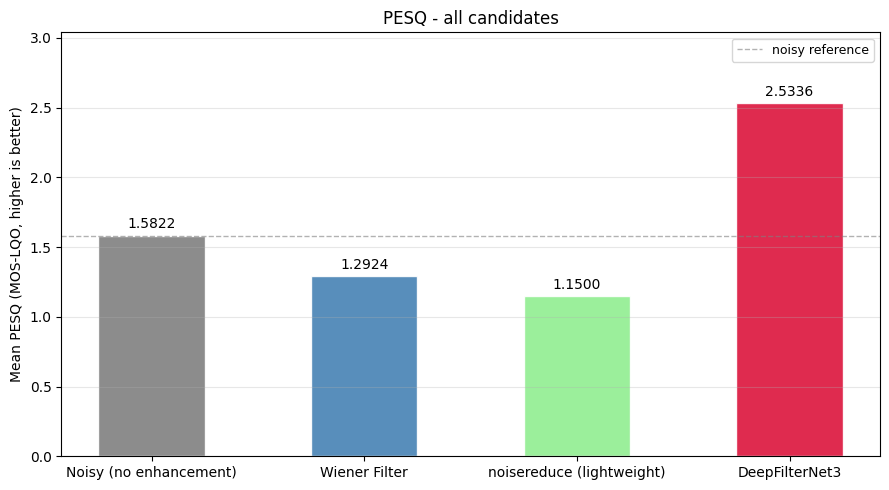

In [87]:
models_order = ["Noisy (no enhancement)", "Wiener Filter", "noisereduce (lightweight)", "DeepFilterNet3"]
colors_map = {
    "Noisy (no enhancement)": "grey",
    "Wiener Filter": "steelblue",
    "noisereduce (lightweight)": "lightgreen",
    "DeepFilterNet3":"crimson",
}

fig, ax = plt.subplots(figsize=(9, 5))
vals  = [results_df.loc[results_df["model"] == m, "mean_pesq"].values[0]
         for m in models_order]
bars = ax.bar(models_order, vals,
              color=[colors_map[m] for m in models_order],
              edgecolor="white", alpha=0.9, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_title("PESQ - all candidates", fontsize=12)
ax.set_ylabel("Mean PESQ (MOS-LQO, higher is better)")
ax.set_ylim(0, max(vals) * 1.2)
ax.axhline(vals[0], color="grey", linestyle="--", linewidth=1, alpha=0.6,
           label="noisy reference")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_pesq.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 STOI comparison

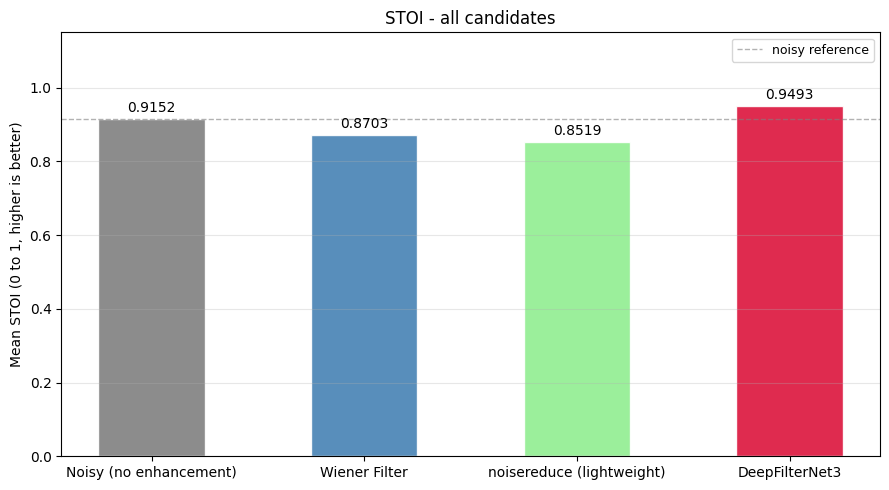

In [88]:
fig, ax = plt.subplots(figsize=(9, 5))
vals = [results_df.loc[results_df["model"] == m, "mean_stoi"].values[0]
        for m in models_order]
bars = ax.bar(models_order, vals,
              color=[colors_map[m] for m in models_order],
              edgecolor="white", alpha=0.9, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_title("STOI - all candidates", fontsize=12)
ax.set_ylabel("Mean STOI (0 to 1, higher is better)")
ax.set_ylim(0, 1.15)
ax.axhline(vals[0], color="grey", linestyle="--", linewidth=1, alpha=0.6,
           label="noisy reference")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_stoi.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.4 RTF comparison

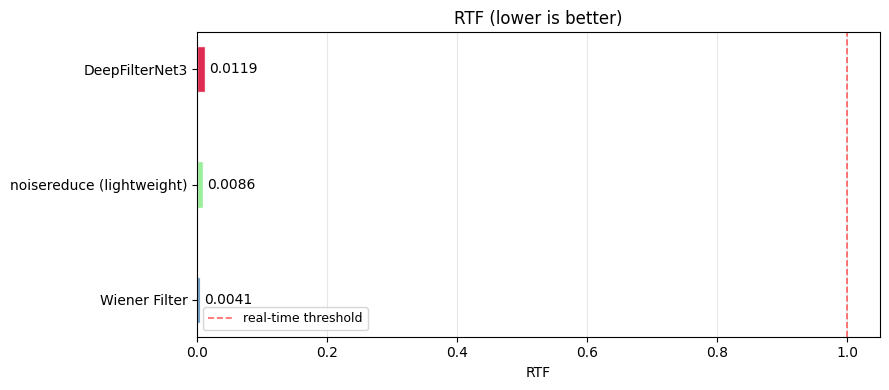

In [91]:
fig, ax = plt.subplots(figsize=(9, 4))

rtf_models = ["Wiener Filter", "noisereduce (lightweight)", "DeepFilterNet3"]
rtf_vals = [results_df.loc[results_df["model"] == m, "rtf"].values[0]
              for m in rtf_models]

bars = ax.barh(rtf_models, rtf_vals,
               color=[colors_map[m] for m in rtf_models],
               edgecolor="white", alpha=0.9, height=0.4)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.2, alpha=0.6,
           label="real-time threshold")

ax.set_title("RTF (lower is better)", fontsize=12)
ax.set_xlabel("RTF")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_rtf.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.5 Delta PESQ by input SNR bin

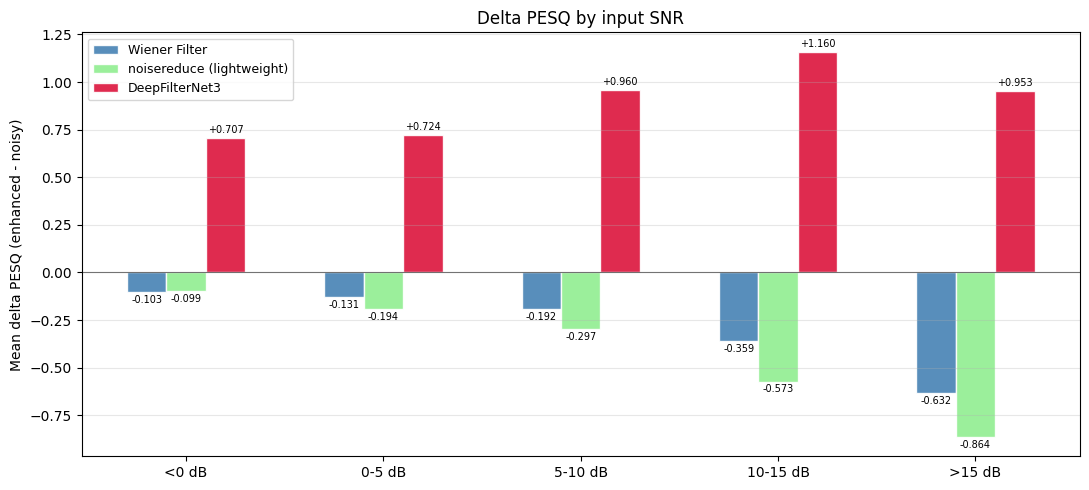

In [93]:
snr_bins = [-10, 0, 5, 10, 15, 25]
snr_labels = ["<0 dB", "0-5 dB", "5-10 dB", "10-15 dB", ">15 dB"]

model_dfs = {
    "Wiener Filter": df_wiener_dns,
    "noisereduce (lightweight)": df_noisereduce_dns,
    "DeepFilterNet3": df_deepfilter_dns,
}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(snr_labels))

for i, (mname, df_m) in enumerate(model_dfs.items()):
    df_m = df_m.copy()
    df_m["snr_bin"] = pd.cut(df_m["snr_target_db"],
                              bins=snr_bins, labels=snr_labels)
    grouped = df_m.groupby("snr_bin", observed=True)["delta_pesq"].mean()
    vals = [grouped.get(label, 0) for label in snr_labels]
    offset = (i - 1) * 0.2
    bars = ax.bar(x + offset, vals, 0.2,
                  label=mname, color=colors_map[mname],
                  edgecolor="white", alpha=0.9)
    ax.bar_label(bars, fmt="%+.3f", padding=2, fontsize=7)

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Delta PESQ by input SNR", fontsize=12)
ax.set_ylabel("Mean delta PESQ (enhanced - noisy)")
ax.set_xticks(x)
ax.set_xticklabels(snr_labels)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_delta_pesq_by_snr.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.6 PESQ distribution per model

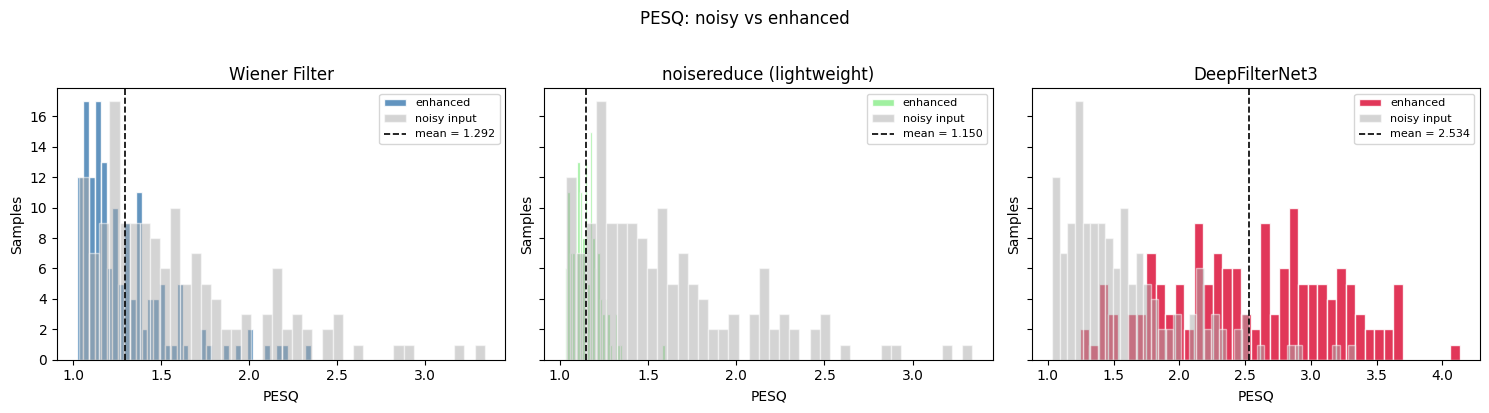

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (mname, df_m) in zip(axes, model_dfs.items()):
    ax.hist(df_m["enh_pesq"].dropna(), bins=40,
            color=colors_map[mname], edgecolor="white", alpha=0.85,
            label="enhanced")
    ax.hist(df_m["noisy_pesq"].dropna(), bins=40,
            color="#aaaaaa", edgecolor="white", alpha=0.5,
            label="noisy input")
    ax.axvline(df_m["enh_pesq"].mean(), color="black", linestyle="--", lw=1.2,
               label=f"mean = {df_m['enh_pesq'].mean():.3f}")
    ax.set_title(mname)
    ax.set_xlabel("PESQ")
    ax.set_ylabel("Samples")
    ax.legend(fontsize=8)

plt.suptitle("PESQ: noisy vs enhanced", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_pesq_distribution.png", dpi=150, bbox_inches="tight")
plt.show()